# eTraGo: electric Transmission Grid optimization

The following notebook shows you how you can run the selected, basic functions of eTraGo.
First, the execution is shown in a minimal system step by step, including information on different functionalities.
In addition, predefined results from a larger calculation are loaded to demonstrate the analysis of results and the interface to underlying distribution grids.

More information on the installation of eTraGo, the described functions, as well as a description of all options, is provided in the __[eTraGo Documentation on read the docs](http://etrago.readthedocs.io/)__

## Import required general and eTraGo specific python packages

In [25]:
import warnings
warnings.filterwarnings('ignore')

from etrago import Etrago
import pypsa

Download data for this notebook

In [26]:
# Insert the path to the downloaded data here
path = "/home/clara/Documents/regon/veroeffetnlichungen_usw/fne_2026/"

# 1 Minimal example demonstrating eTraGo's usage

This section demonstrates the general usage of eTraGo using a minimal example.
The minimal example only considers a few snapshots, and the electrical grid is clustered to a few nodes.

The following subsections will explain and demonstrate the different functionalities given in the schema:

![Image eTraGo's functionalities](https://raw.githubusercontent.com/openego/eTraGo/0.10.1/doc/images/etrago_functionalities.png)


## 1.1 Initialize object and set parameters

All parameters of an eTraGo calculation are stored in etrago.args.
They can be defined via a json-file or as a dictionary. Documentation on all parameters is provided in the read the docs. 

In [3]:
etrago = Etrago(args={}, json_path=path+"etrago_minimal_example/args_minimal_example.json")

In [4]:
# Scenario name
etrago.args["scn_name"]

'eGon2035'

### Snapshots considered in calculation
For a small example, a limited number of snapshots is selected. For larger, annual calculations eTraGo needs more RAM then a normal laptop provides, so calculations are done on a server.
The snapshots are defined as the nth number in a year, so it can be between 1 and 8760.
In this example, the first day of the year is selected:

In [5]:
print(etrago.args["start_snapshot"])
print(etrago.args["end_snapshot"])

1
24


## 1.3 Data model and scenario variation

In [6]:
#etrago.build_network_from_db()
#etrago.adjust_network()

In [7]:
etrago.network = pypsa.Network(path+"etrago_minimal_example/original_grid")

INFO:pypsa.io:Imported network original_grid has buses, generators, lines, links, loads, storage_units, stores, transformers


## 1.4 Complexity Reduction
The data model is characterized by a high spatial (about 8,000 electrical and 600 gas nodes) and temporal resolution (8,760 timesteps). To reduce the complexity of the resulting optimization problem, several methods can be applied.
In this example, we focus on the spatial complexity reduction.

This is how the network looks like in the original resolution:

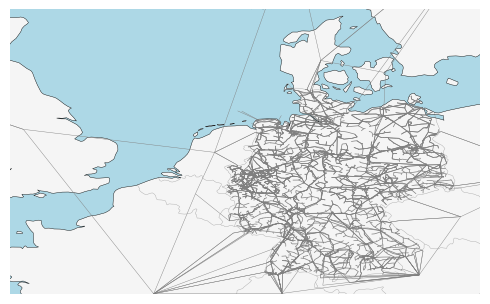

In [8]:
etrago.plot_grid("grey")

In the following, spatial complexity methods are applied. In this minimal example, the electrical network is clustered to 30 nodes.

_Please note that this step can take a few minutes. To save some time, predefined clustering results are loaded here._

In [9]:
# run spatial clustering
#etrago.spatial_clustering()
#etrago.spatial_clustering_gas()
#etrago.network.export_to_csv_folder("clustered_grid")

In [10]:
etrago.network = pypsa.Network(path+"etrago_minimal_example/clustered_grid")

INFO:pypsa.io:Imported network clustered_grid has buses, generators, lines, links, loads, storage_units, stores


Afterwards, the electrical grid looks like this:

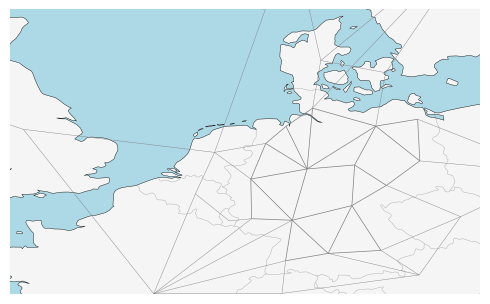

In [11]:
etrago.plot_grid("grey")

## 1.5 Optimization

eTraGo includes different methods to optimize the German energy system, including the eHV/HV grid.
In this example, an integrated LOPF is selected. This optimizes the dispatch of generation and flexibility options as well as grid and storage expansion in one integrated optimization step.

_Please note that the solver glpk needs to be installed for this minimal example._

In [12]:
etrago.optimize()

INFO:pypsa.opf:Performed preliminary steps
INFO:pypsa.opf:Building pyomo model using `kirchhoff` formulation
INFO:pypsa.opf:Solving model using glpk
INFO:pypsa.opf:Optimization successful
INFO:etrago.execute:Time for LOPF [min]: 0.42


# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 484264625.430364
  Upper bound: 484264625.430364
  Number of objectives: 1
  Number of constraints: 34729
  Number of variables: 26024
  Number of nonzeros: 84521
  Sense: minimize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: 0
      Number of created subproblems: 0
  Error rc: 0
  Time: 19.42110848426819
# ----------------------------------------------------------
#   Solution Information
# -----

## 1.6 Result analysis

eTraGo includes different functions to analyze the results.

_Please note that the results of the minimal example are not representative, they are just shown to explain the general usage._

In the following, a map of grid and storage expansion is visualized:

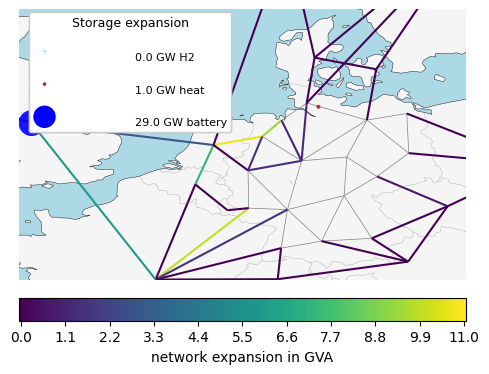

In [13]:
etrago.plot_grid(
    line_colors="expansion_abs",
    bus_colors = "storage_expansion", bus_sizes= 0.000001,
    scaling_store_expansion={"H2": 10,
                            "heat": 10,
                            "battery": 10})

## 1.7 Scenario variation: Limited grid expansion

In [14]:
etrago.args['extra_functionality']={"max_line_ext":1.05}

In [15]:
etrago.optimize()

INFO:pypsa.opf:Performed preliminary steps
INFO:pypsa.opf:Building pyomo model using `kirchhoff` formulation
INFO:etrago.tools.constraints:Added extra_functionality max_line_ext
INFO:pypsa.opf:Solving model using glpk
INFO:pypsa.opf:Optimization successful
INFO:etrago.execute:Time for LOPF [min]: 0.46


# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 484553282.633222
  Upper bound: 484553282.633222
  Number of objectives: 1
  Number of constraints: 34730
  Number of variables: 26024
  Number of nonzeros: 84587
  Sense: minimize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: 0
      Number of created subproblems: 0
  Error rc: 0
  Time: 21.023223638534546
# ----------------------------------------------------------
#   Solution Information
# ----

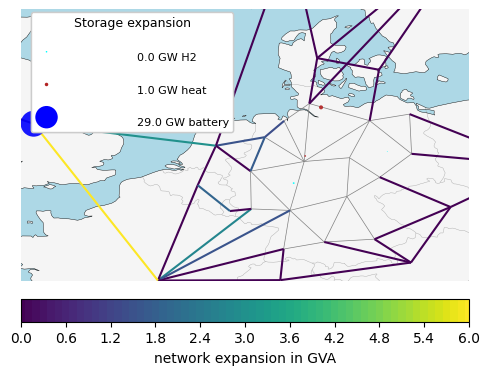

In [16]:
etrago.plot_grid(
    line_colors="expansion_abs",
    bus_colors = "storage_expansion", bus_sizes= 0.000001,
    scaling_store_expansion={"H2": 10,
                            "heat": 10,
                            "battery": 10})

# 2 Analyzing results of a representative calculation

Loading predefined results (https://zenodo.org/records/10160482)

## 2.1 Loading predefined results

In [17]:
etrago_larger_model = Etrago(csv_folder_name=path+"etrago_predefined_results/etrago_lowflex_network")

INFO:pypsa.io:Imported network etrago_lowflex_network has buses, generators, lines, links, loads, storage_units, stores
                    No args.json in /home/clara/Documents/regon/veroeffetnlichungen_usw/fne_2026/etrago_predefined_results/etrago_lowflex_network available.
                    
INFO:etrago.network:
                        No disaggregated network available.
                        
INFO:etrago.network:
                            No separate market model available.
                            


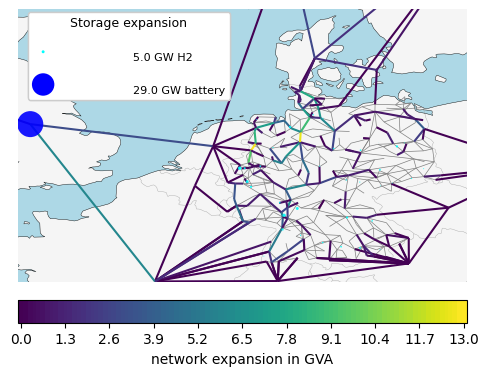

In [18]:
etrago_larger_model.plot_grid(
    line_colors="expansion_abs",
    bus_colors = "storage_expansion", bus_sizes= 0.000001,
    scaling_store_expansion={"H2": 1,
                            "battery": 10})

eTraGo also includes functions to calculate general results as tables, such as system costs and total grid expansion:

In [19]:
etrago_larger_model.calc_results()
etrago_larger_model.results.loc["annual electrical grid investment costs"]

unit                 EUR/a
value    1208150163.949301
Name: annual electrical grid investment costs, dtype: object

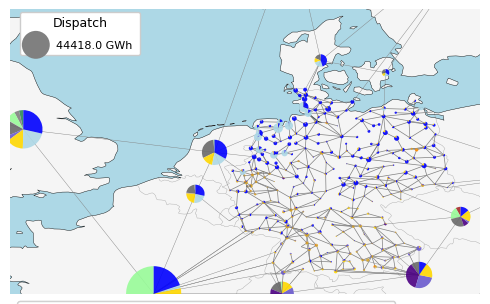

In [20]:
etrago_larger_model.plot_grid(
    line_colors="grey",
    bus_colors = "gen_dist",
    bus_sizes= 1e-8,
    timesteps = range(1752))

## 2.2 Desaggregation results to the original resolution - Interface to eDisGo

The results can be disaggregated to the original resolution in both temporal and spatial dimension. This is esp. required for the interface to the underlying distribution grids.

In [21]:
etrago_larger_model.disaggregated_network = pypsa.Network(path+"etrago_predefined_results/lowflex_network_disaggregated.nc")

INFO:pypsa.io:Imported network lowflex_network_disaggregated.nc has buses, generators, lines, links, loads, storage_units, stores, transformers


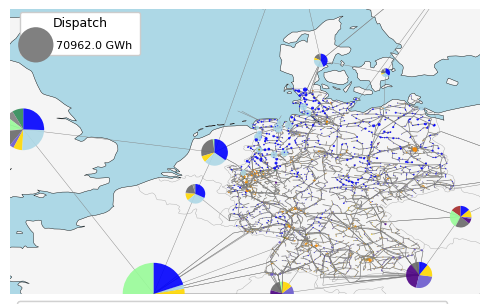

In [22]:
etrago_larger_model.plot_grid(
    line_colors="grey",
    apply_on = "disaggreagted_network",
    bus_colors = "gen_dist",
    bus_sizes= 1e-8,
    timesteps = range(1752))

In [23]:
mv_id = "33128"

gens = etrago_larger_model.disaggregated_network.generators[etrago_larger_model.disaggregated_network.generators.bus==mv_id]

<Axes: xlabel='snapshot'>

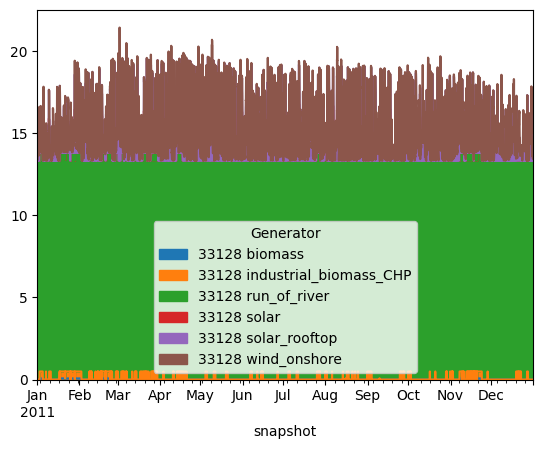

In [24]:
etrago_larger_model.disaggregated_network.generators_t.p[gens.index].plot(kind="area", stacked = True)

These dispatch time series per HV/MV substation are transferd to the underlying MV/LV grids. 